In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.varmax import VARMAX

In [2]:
!pip install matplotlib statsmodels


In [4]:
df=pd.read_csv("timeseries.csv")
df.columns

Index(['Date', 'Crop_Type', 'Soil_Type', 'Soil_pH', 'Temperature', 'Humidity',
       'Wind_Speed', 'N', 'P', 'K', 'Crop_Yield', 'Soil_Quality'],
      dtype='object')

In [5]:
df['Date']=pd.to_datetime(df['Date'])

In [6]:
df.set_index('Date',inplace=True)

In [7]:
df=df.select_dtypes(include="number")

In [8]:
df.head()

,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality
Date,,,,,,,,,
2014-01-01,5.50,9.440599,80.000000,10.956707,60.5,45.0,31.5,0.000000,22.833333
2014-01-01,6.50,20.052576,79.947424,8.591577,84.0,66.0,50.0,104.871310,66.666667
2014-01-01,5.50,12.143099,80.000000,7.227751,71.5,54.0,38.5,0.000000,27.333333
2014-01-01,6.75,19.751848,80.000000,2.682683,50.0,40.0,30.0,58.939796,35.000000
2014-01-01,5.50,16.110395,80.000000,7.696070,49.5,45.0,38.5,32.970413,22.166667


In [9]:
df=df.resample("D").mean()

In [10]:
df

,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality
Date,,,,,,,,,
2014-01-01,6.275,15.994309,79.994742,8.163837,64.55,51.60,40.50,37.073799,35.920833
2014-01-02,6.575,15.639907,79.998234,9.669001,67.00,54.05,43.15,34.636737,32.750000
2014-01-03,6.450,15.156596,79.028168,11.052915,66.50,53.30,42.35,22.107670,41.579167
2014-01-04,6.950,15.026332,79.479529,10.162655,68.70,55.80,44.75,28.197627,40.587500
2014-01-05,6.400,13.828252,80.000000,10.523809,68.45,55.65,45.00,26.062550,51.362500
...,...,...,...,...,...,...,...,...,...
2023-12-27,6.325,17.876878,79.534930,10.175505,65.55,52.80,41.90,36.000448,31.670833
2023-12-28,6.700,14.112902,79.710214,11.310018,67.85,54.50,43.50,21.939957,41.320833
2023-12-29,6.650,16.059964,79.275568,10.262287,65.45,52.40,41.40,34.359710,38.162500


<Figure size 1200x400 with 0 Axes>

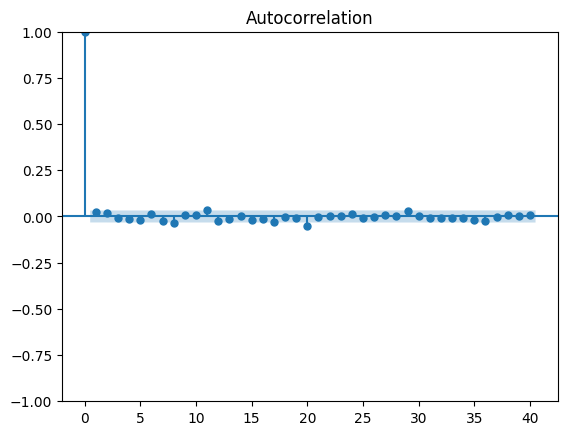

<Figure size 1200x400 with 0 Axes>

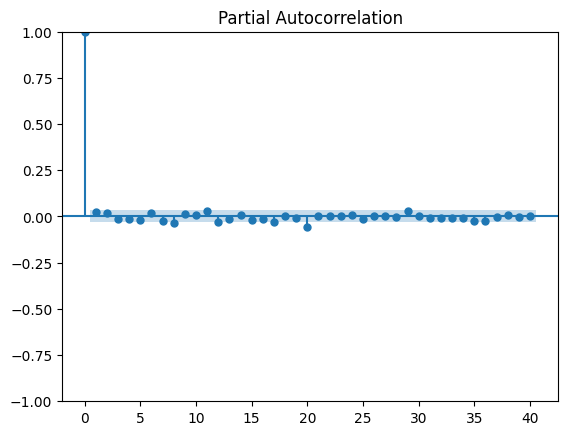

In [11]:
ts = df.iloc[:, 0]

# 1. Plot the Time Series


# 2. ACF and PACF
plt.figure(figsize=(12,4))
plot_acf(ts, lags=40)
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(ts, lags=40)
plt.show()

In [12]:
adf_result = adfuller(ts.dropna())  # drop missing values if any
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value}")

if adf_result[1] < 0.05:
    print("\nThe series is likely stationary.")
else:
    print("\nThe series is non-stationary. Consider differencing or transformation.")


ADF Statistic: -58.82289890001849
p-value: 0.0
Critical Values:
   1%: -3.4321423592450104
   5%: -2.862331964581231
   10%: -2.567191574740688

The series is likely stationary.


In [13]:
from statsmodels.tsa.arima.model import ARIMA

In [14]:
model=ARIMA(ts, order=(1,1,1))
model_fit=model.fit()

In [15]:
forecast=model_fit.forecast(steps=10)
forecast

2024-01-01    6.595218
2024-01-02    6.602485
2024-01-03    6.602680
2024-01-04    6.602685
2024-01-05    6.602685
2024-01-06    6.602685
2024-01-07    6.602685
2024-01-08    6.602685
2024-01-09    6.602685
2024-01-10    6.602685
Freq: D, Name: predicted_mean, dtype: float64

In [16]:
print(df.columns.tolist())


['Soil_pH', 'Temperature', 'Humidity', 'Wind_Speed', 'N', 'P', 'K', 'Crop_Yield', 'Soil_Quality']


C:\Users\Vaishnavi\AppData\Local\Temp\ipykernel_2684\3335324212.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_num = df[numerical_cols].fillna(method='ffill')


ADF Statistic: -6.236677196899428
p-value: 4.8067318744241745e-08
                               SARIMAX Results                                
Dep. Variable:             Crop_Yield   No. Observations:                 3652
Model:               SARIMAX(1, 1, 1)   Log Likelihood              -10606.902
Date:                Fri, 03 Oct 2025   AIC                          21235.805
Time:                        16:49:34   BIC                          21304.035
Sample:                    01-01-2014   HQIC                         21260.103
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Soil_pH         -0.3124      0.349     -0.895      0.371      -0.997       0.372
Temperature      5.1120      0.046    112.282      0.000   

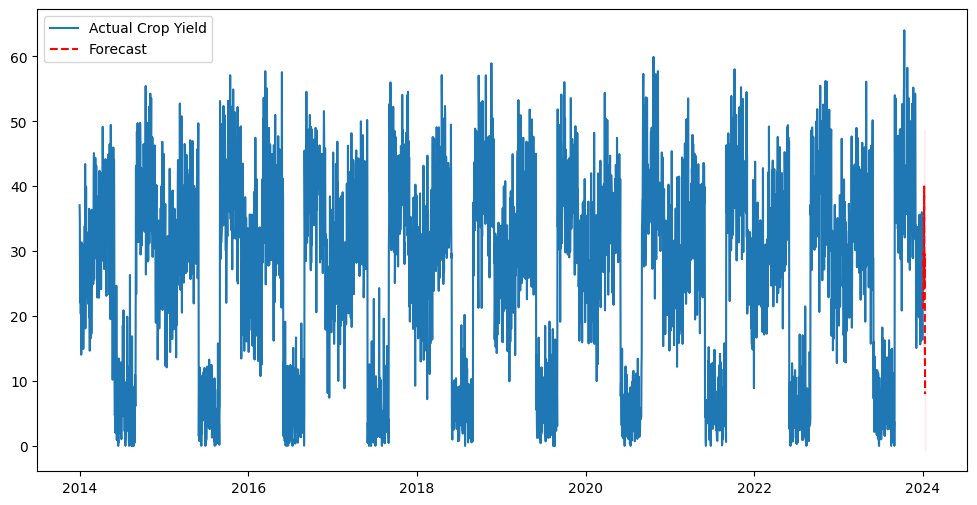

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Step 1: Load and preprocess
df = pd.read_csv("timeseries.csv", parse_dates=["Date"])
df['Date'] = pd.to_datetime(df['Date'])
df.set_index("Date", inplace=True)

# Keep only numeric columns
df = df.select_dtypes(include="number")

# Fix duplicate dates
df = df.groupby(df.index).mean()

# Ensure continuous daily frequency
df = df.asfreq("D")
df = df.interpolate(method="time")

# Target variable = Crop Yield
target = df["Crop_Yield"]

# Exogenous variables (Rainfall, Temperature, Fertilizer etc.)
exog = df.drop(columns=["Crop_Yield"])

# Step 2: Stationarity check
def check_stationarity(series):
    result = adfuller(series.dropna())
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

check_stationarity(target)

# Step 3: Train SARIMAX model (p,d,q order chosen via ACF/PACF or grid search)
model = SARIMAX(
    target,
    order=(1,1,1),
    exog=exog,
    seasonal_order=(0,0,0,0)
)
fit = model.fit(disp=False)
print(fit.summary())

# Step 4: Forecast
forecast_steps = 10
future_exog = exog.iloc[-forecast_steps:]  # future values of exogenous vars

forecast = fit.get_forecast(steps=forecast_steps, exog=future_exog)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

print("\nForecasted Crop Yield:")
print(forecast_mean)

# Step 5: Plot results
plt.figure(figsize=(12,6))
plt.plot(target.index, target, label="Actual Crop Yield")
plt.plot(forecast_mean.index, forecast_mean, linestyle="--", color="red", label="Forecast")
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:,0],
                 forecast_ci.iloc[:,1],
                 color="pink", alpha=0.3)

plt.legend()
plt.show()
fit.save("sarimax_model.pkl")

ADF Statistic: -6.236677196899428
p-value: 4.8067318744241745e-08
                               SARIMAX Results                                
Dep. Variable:             Crop_Yield   No. Observations:                 3652
Model:               SARIMAX(1, 1, 1)   Log Likelihood              -10606.902
Date:                Fri, 03 Oct 2025   AIC                          21235.805
Time:                        16:49:46   BIC                          21304.035
Sample:                    01-01-2014   HQIC                         21260.103
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Soil_pH         -0.3124      0.349     -0.895      0.371      -0.997       0.372
Temperature      5.1120      0.046    112.282      0.000   

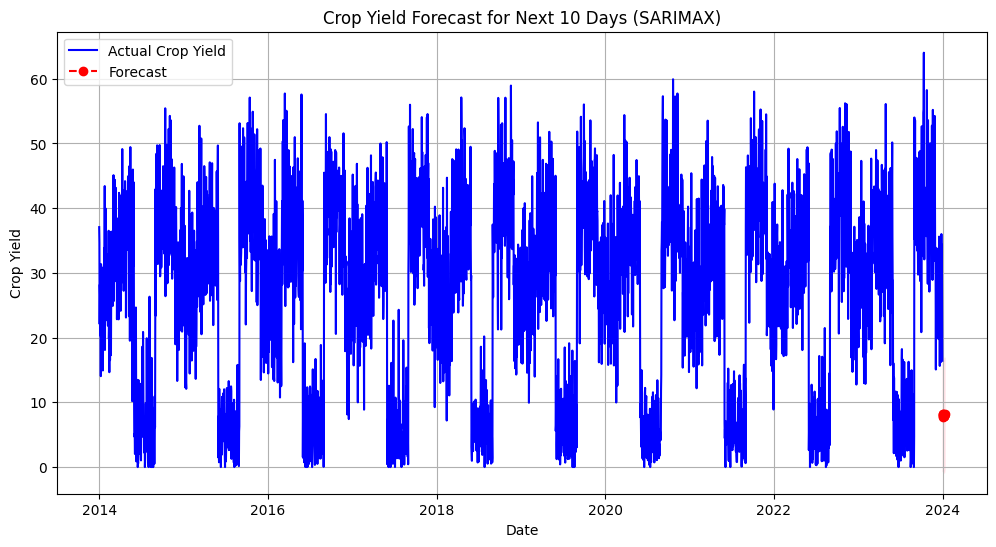

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

# -------------------------------
# Step 1: Load and preprocess
# -------------------------------
df = pd.read_csv("timeseries.csv", parse_dates=["Date"])
df['Date'] = pd.to_datetime(df['Date'])
df.set_index("Date", inplace=True)

# Keep only numeric columns
df = df.select_dtypes(include="number")

# Fix duplicate dates by taking mean
df = df.groupby(df.index).mean()

# Ensure continuous daily frequency
df = df.asfreq("D")
df = df.interpolate(method="time")

# Target variable
target = df["Crop_Yield"]

# Exogenous variables
exog = df.drop(columns=["Crop_Yield"])

# -------------------------------
# Step 2: Stationarity check
# -------------------------------
def check_stationarity(series):
    result = adfuller(series.dropna())
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    
check_stationarity(target)

# -------------------------------
# Step 3: Train SARIMAX model
# -------------------------------
model = SARIMAX(
    target,
    order=(1,1,1),
    exog=exog,
    seasonal_order=(0,0,0,0)
)
fit = model.fit(disp=False)
print(fit.summary())

# -------------------------------
# Step 4: Generate synthetic exogenous for next 10 days
# -------------------------------
forecast_steps = 10
future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1),
                             periods=forecast_steps, freq='D')

# Generate synthetic exogenous variables by trend + small noise
last_exog = exog.iloc[-1]
future_exog = pd.DataFrame(
    [last_exog.values + np.random.normal(0, 0.01, size=len(last_exog)) for _ in range(forecast_steps)],
    columns=exog.columns,
    index=future_dates
)

# -------------------------------
# Step 5: Forecast next 10 days
# -------------------------------
forecast = fit.get_forecast(steps=forecast_steps, exog=future_exog)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

print("Forecasted Crop Yield for next 10 days:")
print(forecast_mean)

# -------------------------------
# Step 6: Plot results
# -------------------------------
plt.figure(figsize=(12,6))
plt.plot(target.index, target, label="Actual Crop Yield", color="blue")
plt.plot(forecast_mean.index, forecast_mean, linestyle="--", color="red", marker="o", label="Forecast")
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:,0],
                 forecast_ci.iloc[:,1],
                 color="pink", alpha=0.3)
plt.title("Crop Yield Forecast for Next 10 Days (SARIMAX)")
plt.xlabel("Date")
plt.ylabel("Crop Yield")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Step 7: Save model
# -------------------------------
fit.save("sarimax_model.pkl")


ADF Statistic: -6.236677196899428
p-value: 4.8067318744241745e-08
                               SARIMAX Results                                
Dep. Variable:             Crop_Yield   No. Observations:                 3652
Model:               SARIMAX(1, 1, 1)   Log Likelihood              -10606.902
Date:                Fri, 03 Oct 2025   AIC                          21235.805
Time:                        16:53:44   BIC                          21304.035
Sample:                    01-01-2014   HQIC                         21260.103
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Soil_pH         -0.3124      0.349     -0.895      0.371      -0.997       0.372
Temperature      5.1120      0.046    112.282      0.000   

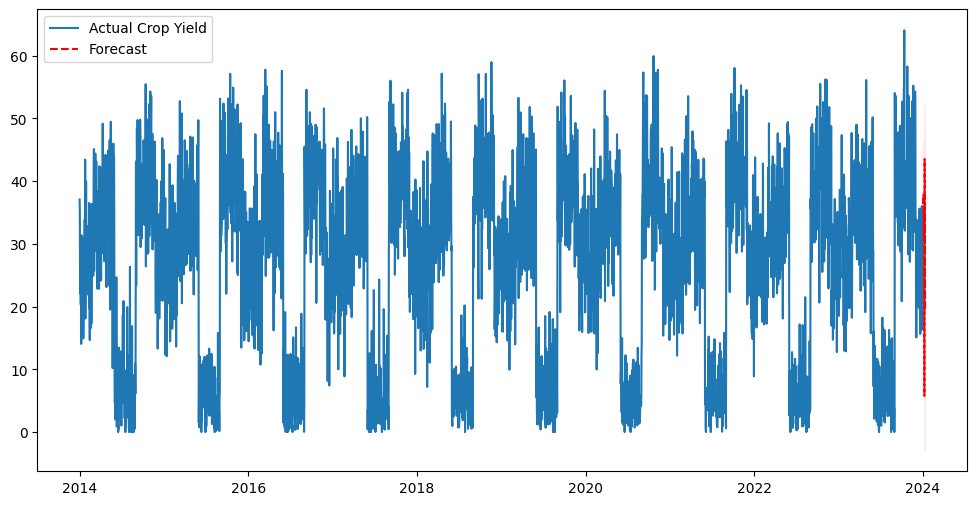

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Step 1: Load and preprocess
df = pd.read_csv("timeseries.csv", parse_dates=["Date"])
df['Date'] = pd.to_datetime(df['Date'])
df.set_index("Date", inplace=True)

# Keep only numeric columns
df = df.select_dtypes(include="number")

# Fix duplicate dates
df = df.groupby(df.index).mean()

# Ensure continuous daily frequency
df = df.asfreq("D")
df = df.interpolate(method="time")

# Target variable = Crop Yield
target = df["Crop_Yield"]

# Exogenous variables (Rainfall, Temperature, Fertilizer etc.)
exog = df.drop(columns=["Crop_Yield"])
exog_columns = exog.columns.tolist()

# Step 2: Stationarity check
def check_stationarity(series):
    result = adfuller(series.dropna())
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

check_stationarity(target)

# Step 3: Train SARIMAX model
model = SARIMAX(
    target,
    order=(1,1,1),
    exog=exog,
    seasonal_order=(0,0,0,0)
)
fit = model.fit(disp=False)
print(fit.summary())

# Step 4: Generate synthetic future exogenous data
def generate_synthetic_exog(steps: int):
    historical_exog = exog.values
    n_features = historical_exog.shape[1]
    synthetic_data = []

    for _ in range(steps):
        base_row = historical_exog[np.random.randint(0, len(historical_exog))]

        # Add small Gaussian noise
        noise = np.random.normal(0, 0.02, size=n_features)

        # Occasionally add larger noise to simulate outliers
        if np.random.rand() < 0.2:
            noise += np.random.normal(0, 0.1, size=n_features)

        synthetic_row = base_row + noise
        synthetic_data.append(synthetic_row)

    # Generate future dates
    last_date = df.index[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1),
                                 periods=steps, freq="D")

    return pd.DataFrame(synthetic_data, columns=exog_columns, index=future_dates)

# Step 5: Forecast
forecast_steps = 10
future_exog = generate_synthetic_exog(forecast_steps)

forecast = fit.get_forecast(steps=forecast_steps, exog=future_exog)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

print("\nForecasted Crop Yield:")
print(forecast_mean)

# Step 6: Plot results
plt.figure(figsize=(12,6))
plt.plot(target.index, target, label="Actual Crop Yield")
plt.plot(forecast_mean.index, forecast_mean, linestyle="--", color="red", label="Forecast")
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:,0],
                 forecast_ci.iloc[:,1],
                 color="pink", alpha=0.3)

plt.legend()
plt.show()

# Save trained model
fit.save("sarimax_model2.pkl")


c:\Users\Vaishnavi\OneDrive\Desktop\info\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Vaishnavi\OneDrive\Desktop\info\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Vaishnavi\OneDrive\Desktop\info\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMAX model saved successfully!
